# Minimal FNN · population spikes → HD + radius

Run All on **hhw9l84**, kernel **Python (rfmapping)**, from `~/Developer/rfmapping/fnn`.
Sample: **m19 / 260827_10 / Probe A / hp4**.

[Ajabi et al. (2023), Methods](https://www.nature.com/articles/s41586-023-05813-2)
maps population activity to two coordinates using three branches. The product
`g × (z1, z2)` is trained against `(cos HD, sin HD)`; the unmultiplied
`(z1, z2)` provides the polar representation.
The 64-unit architecture, activations, and L2 coefficient below follow
[Extended Data Fig. 4d](https://www.nature.com/articles/s41586-023-05813-2/figures/9).

`../../glm/minimal_glm.ipynb` supplies the session/path/clock conventions.
Its selected unit is 261; this decoder needs a **population**, so it reads the
good-unit labels. GLM predicts spikes from behavior; this FNN predicts HD
from simultaneously recorded spikes.

This is an implementation check on our RF session. Optimizer, normalization,
100-ms bins, unit-rate cutoff, and chronological split are explicit local choices.
The session is not identified as the paper's stable baseline or cue-rotation
experiment, and these units have not been classified here as ADN/HD cells.
A supervised ring and decoding accuracy alone do not demonstrate an attractor.


## 1. Settings

All times are seconds on the ADC clock. A sample uses spike counts inside a
100-ms bin and HD at its midpoint. No temporal smoothing or lagged inputs.


In [10]:
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.linear_model import Ridge
from torch import nn

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "savefig.transparent": False,
    "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black",
    "legend.facecolor": "white", "legend.edgecolor": "black",
    "legend.labelcolor": "black", "legend.framealpha": 1.0,
})

animal = "m19"
date = "260827"
session_id = 10
headplate = "hp4"
session_dir = Path(f"/mnt/senzailab/Kai/#Recording/{animal}/{date}/{date}_{session_id}")
data_dir = session_dir / "data"
kilosort_dir = session_dir / f"kilosort/ProbeA/kilosort_{session_id}"
output_dir = Path.cwd() / "outputs" / f"{animal}_{date}_{session_id}_probeA"

bin_size = 0.1
min_train_rate = 1.0  # Hz, applied only to the training interval.
train_fraction = 0.7
validation_end_fraction = 0.8
guard_s = 1.0
camera_channel = 1  # Zero-based ADC channel, as in minimal_glm.
camera_threshold = 11000
seed = 0
l2 = 0.001
learning_rate = 0.001
batch_size = 256
max_epochs = 200
patience = 20

torch.set_num_threads(4)
torch.manual_seed(seed)
np.random.seed(seed)
torch.use_deterministic_algorithms(True)


## 2. Which files are read?

| File, relative to the session | Use |
|---|---|
| `data/session_info.json` | Locate raw ADC recording and channel count |
| ADC `timestamps.npy`, `continuous.dat` (resolved below) | Camera exposure midpoints |
| `data/processed/head_direction.json` | hp4 angle and original frame indices |
| `260827.calib` | Subtract `screen_center` from HD, as in minimal_glm |
| `data/on_list_times.npy` | Analysis interval: first to last stimulus edge |
| `data/probeA/adc_spike_time.npy` | ADC-aligned spike times, in seconds |
| `kilosort/ProbeA/kilosort_10/spike_clusters.npy` | Cluster ID for each spike, in the same order |
| `kilosort/ProbeA/kilosort_10/cluster_group.tsv` | `cluster_id` and `KSLabel == "good"` |

The table printed below resolves every absolute filename. No trial MAT,
Motive CSV, cached GLM output, or single-unit fit is needed. These explicit
filenames and the KSLabel column match the selected session; other datasets
must provide the same layout or have their paths/schema edited here.


In [11]:
files = {
    "session_info": data_dir / "session_info.json",
    "head_direction": data_dir / "processed/head_direction.json",
    "calibration": session_dir / f"{date}.calib",
    "trial_edges": data_dir / "on_list_times.npy",
    "spike_times": data_dir / "probeA/adc_spike_time.npy",
    "spike_clusters": kilosort_dir / "spike_clusters.npy",
    "unit_labels": kilosort_dir / "cluster_group.tsv",
}
session_info = json.loads(files["session_info"].read_text())["session_info"]
adc_dir = (
    Path(session_info["base_path"]) / session_info["record_nodes"]
    / session_info["experiment_id"] / session_info["recording_name"]
    / "continuous" / session_info["continuous_ADC_folder"]
)
files["adc_timestamps"] = adc_dir / "timestamps.npy"
files["adc_continuous"] = adc_dir / "continuous.dat"
display(pd.DataFrame([
    {"input": name, "absolute_path": str(path), "bytes": path.stat().st_size}
    for name, path in files.items()
]).style.hide(axis="index").set_properties(**{"text-align": "left"}))


input,absolute_path,bytes
session_info,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/data/session_info.json,771
head_direction,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/data/processed/head_direction.json,5658785
calibration,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/260827.calib,364
trial_edges,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/data/on_list_times.npy,96136
spike_times,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/data/probeA/adc_spike_time.npy,39397864
spike_clusters,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/kilosort/ProbeA/kilosort_10/spike_clusters.npy,19698996
unit_labels,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/kilosort/ProbeA/kilosort_10/cluster_group.tsv,3660
adc_timestamps,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/260827/Record Node 102/experiment1/recording1/continuous/OneBox-107.OneBox-ADC/timestamps.npy,300767328
adc_continuous,/mnt/senzailab/Kai/#Recording/m19/260827/260827_10/260827/Record Node 102/experiment1/recording1/continuous/OneBox-107.OneBox-ADC/continuous.dat,902301600


## 3. Read HD and its camera clock

Match minimal_glm's complete **low-pulse midpoint** clock. ADC timestamps
and aligned spike times are already seconds: do not divide by a sample rate.
Use the JSON's `frames` indices, discard frames lacking a complete pulse,
and subtract this session's `screen_center`. Interpolate unwrapped angles;
bins spanning missing camera support are excluded below.


In [12]:
adc_time = np.load(files["adc_timestamps"], mmap_mode="r")
camera = np.memmap(files["adc_continuous"], dtype=np.int16, mode="r")[
    camera_channel::session_info["ADC_input_channel"]
]
low = np.r_[False, camera < camera_threshold, False]
low_start = np.flatnonzero(~low[:-1] & low[1:])
low_end = np.flatnonzero(low[:-1] & ~low[1:])
complete = (low_start > 0) & (low_end < len(camera))
pulse_time = (adc_time[low_start[complete]] + adc_time[low_end[complete]]) / 2
del adc_time, camera, low, low_start, low_end

hd_data = json.loads(files["head_direction"].read_text())[headplate]
calibration = json.loads(files["calibration"].read_text())
frames = np.asarray(hd_data["frames"], dtype=int)
frame_hd = np.asarray(hd_data["head_direction_deg"], dtype=float)
supported_frame = (frames >= 0) & (frames < len(pulse_time)) & np.isfinite(frame_hd)
frame_time = pulse_time[frames[supported_frame]]
frame_hd = (frame_hd[supported_frame] - calibration["screen_center"]) % 360
unwrapped_hd = np.unwrap(np.deg2rad(frame_hd))
frame_interval = np.median(np.diff(frame_time))
assert np.all(np.diff(frame_time) > 0)

print(f"Complete camera pulses: {len(pulse_time):,}")
print(f"Usable HD frames: {len(frame_time):,}; omitted: {len(frames) - len(frame_time)}")
print(f"Median camera interval: {frame_interval * 1000:.3f} ms")
print(f"HD clock: {frame_time[0]:.6f} to {frame_time[-1]:.6f} ADC seconds")


Complete camera pulses: 148,146
Usable HD frames: 148,146; omitted: 1
Median camera interval: 8.333 ms
HD clock: 3575.891906 to 4810.363588 ADC seconds


## 4. Read the population and make aligned samples

Counts use half-open bins `[start, end)`. The same spike mask indexes the
ADC times and cluster IDs. A row of `counts` is one time bin; a column is one
unit. This is the data matrix the network will read.


In [13]:
trial_edges = np.load(files["trial_edges"])
adc_spikes = np.load(files["spike_times"])
clusters = np.load(files["spike_clusters"])
labels = pd.read_csv(files["unit_labels"], sep="\t")
unit_ids = np.sort(labels.loc[labels["KSLabel"] == "good", "cluster_id"].to_numpy())
good_unit_count = len(unit_ids)
assert adc_spikes.shape == clusters.shape
assert len(unit_ids) > 1 and len(unit_ids) == len(np.unique(unit_ids))

start_s = max(trial_edges[0], frame_time[0])
stop_s = min(trial_edges[-1], frame_time[-1])
bin_count = int(np.floor((stop_s - start_s) / bin_size))
time_edges = start_s + np.arange(bin_count + 1) * bin_size
time = (time_edges[:-1] + time_edges[1:]) / 2

event = (
    (adc_spikes >= time_edges[0]) & (adc_spikes < time_edges[-1])
    & np.isin(clusters, unit_ids)
)
event_bin = np.searchsorted(time_edges, adc_spikes[event], side="right") - 1
event_unit = np.searchsorted(unit_ids, clusters[event])
counts = np.bincount(
    event_bin * len(unit_ids) + event_unit,
    minlength=bin_count * len(unit_ids),
).reshape(bin_count, len(unit_ids))
assert counts.sum() == event.sum()

left_frame = np.searchsorted(frame_time, time_edges[:-1], side="right") - 1
right_frame = np.searchsorted(frame_time, time_edges[1:], side="left")
gap_count = np.r_[0, np.cumsum(np.diff(frame_time) > 2 * frame_interval)]
valid = gap_count[right_frame] == gap_count[left_frame]
hd_deg = np.rad2deg(np.interp(time, frame_time, unwrapped_hd)) % 360
sample_start = time_edges[:-1][valid]
sample_end = time_edges[1:][valid]
time, hd_deg, counts = time[valid], hd_deg[valid], counts[valid]
rate = counts.astype(np.float32) / bin_size

print(f"Analysis: {time_edges[0]:.6f} to {time_edges[-1]:.6f} ADC seconds")
print(f"Good units: {good_unit_count}; aligned bins: {len(time):,}; gap bins removed: {(~valid).sum()}")
display(pd.DataFrame({
    "ADC midpoint (s)": time[:5],
    "from first stimulus (s)": time[:5] - trial_edges[0],
    "HD (deg)": hd_deg[:5],
    "population spike count": counts[:5].sum(axis=1),
}))


Analysis: 3601.315978 to 4801.015978 ADC seconds
Good units: 159; aligned bins: 11,997; gap bins removed: 0


,ADC midpoint (s),from first stimulus (s),HD (deg),population spike count
0,3601.365978,0.05,257.181334,299
1,3601.465978,0.15,258.866981,274
2,3601.565978,0.25,265.271319,261
3,3601.665978,0.35,265.709672,235
4,3601.765978,0.45,265.891524,313


## 5. Chronological train / validation / test

70% for fitting, the next 10% for early stopping, the last 20% for final
testing. A one-second guard follows each split. Unit selection and per-unit
mean/SD use **training rows only**. The model never receives HD, time,
stimulus identity, or trial number as an input.


In [14]:
train_end = start_s + (time_edges[-1] - start_s) * train_fraction
validation_end = start_s + (time_edges[-1] - start_s) * validation_end_fraction
train = sample_end <= train_end
validation = (sample_start >= train_end + guard_s) & (sample_end <= validation_end)
test = sample_start >= validation_end + guard_s
assert train.any() and validation.any() and test.any()
assert not np.any(train & validation | train & test | validation & test)

keep = (rate[train].mean(axis=0) >= min_train_rate) & (rate[train].std(axis=0) > 0)
unit_ids, counts, rate = unit_ids[keep], counts[:, keep], rate[:, keep]
assert len(unit_ids) > 1
input_mean = rate[train].mean(axis=0)
input_scale = rate[train].std(axis=0)
X = ((rate - input_mean) / input_scale).astype(np.float32)
target = np.column_stack([np.cos(np.deg2rad(hd_deg)), np.sin(np.deg2rad(hd_deg))]).astype(np.float32)
assert np.isfinite(X).all() and np.isfinite(target).all()
X_tensor = torch.from_numpy(X)
target_tensor = torch.from_numpy(target)
split_masks = {"train": train, "validation": validation, "test": test}
split_summary = pd.DataFrame([
    {"split": name, "bins": int(mask.sum()), "exposure_s": float(mask.sum() * bin_size),
     "first_ADC_s": float(sample_start[mask][0]), "last_ADC_s": float(sample_end[mask][-1])}
    for name, mask in split_masks.items()
])
print(f"X: {X.shape} (time × selected units); target: {target.shape}")
print(f"Selected unit IDs ({len(unit_ids)}): {unit_ids.tolist()}")
display(split_summary)


X: (11997, 127) (time × selected units); target: (11997, 2)
Selected unit IDs (127): [3, 6, 7, 9, 16, 19, 24, 26, 27, 29, 32, 38, 39, 40, 43, 47, 50, 59, 60, 64, 74, 75, 78, 79, 82, 86, 87, 94, 104, 105, 108, 111, 112, 116, 123, 124, 128, 130, 134, 135, 136, 140, 147, 149, 154, 157, 159, 161, 166, 169, 170, 177, 178, 182, 185, 186, 189, 191, 200, 201, 202, 206, 209, 215, 220, 221, 224, 226, 229, 233, 234, 241, 243, 245, 247, 249, 254, 257, 261, 263, 264, 266, 267, 270, 275, 278, 280, 281, 285, 286, 292, 294, 298, 301, 307, 314, 320, 324, 325, 334, 341, 342, 348, 354, 355, 357, 364, 369, 370, 382, 388, 393, 395, 397, 401, 407, 410, 411, 414, 417, 424, 425, 426, 433, 439, 445, 448]


,split,bins,exposure_s,first_ADC_s,last_ADC_s
0,train,8397,839.7,3601.315978,4441.015978
1,validation,1189,118.9,4442.115978,4561.015978
2,test,2389,238.9,4562.115978,4801.015978


## 6. Three-branch FNN

The figure specifies `N → 64 → 64 → 1(tanh)` for each coordinate branch,
and `N → 64 → 1(ReLU)` for g; hidden activations are ReLU.
Optimize `mean(sum((g*z − target)^2, axis=1)) + 0.001 * sum(weight^2)`.

Here L2 applies to every Linear weight matrix, not its bias. Adam settings
and a g branch initialized at 1 are local implementation choices.
Decode with `atan2(z2, z1)`. Keep both `R = hypot(z1, z2)` and `1/g`:
they agree only to the extent that the product output has unit norm.


In [15]:
class PolarFNN(nn.Module):
    def __init__(self, n_units):
        super().__init__()

        def coordinate_branch():
            return nn.Sequential(
                nn.Linear(n_units, 64), nn.ReLU(),
                nn.Linear(64, 64), nn.ReLU(),
                nn.Linear(64, 1), nn.Tanh(),
            )

        self.z1 = coordinate_branch()
        self.z2 = coordinate_branch()
        self.g = nn.Sequential(nn.Linear(n_units, 64), nn.ReLU(), nn.Linear(64, 1), nn.ReLU())
        nn.init.zeros_(self.g[2].weight)
        nn.init.ones_(self.g[2].bias)

    def forward(self, x):
        z = torch.cat([self.z1(x), self.z2(x)], dim=1)
        g = self.g(x)
        return g * z, z, g


model = PolarFNN(X.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
train_rows = torch.from_numpy(np.flatnonzero(train))
history = []
best_validation = float("inf")
best_epoch = 0
best_state = None

for epoch in range(1, max_epochs + 1):
    model.train()
    rows = train_rows[torch.randperm(len(train_rows))]
    for batch in rows.split(batch_size):
        optimizer.zero_grad()
        prediction, _, _ = model(X_tensor[batch])
        mse = (prediction - target_tensor[batch]).square().sum(dim=1).mean()
        penalty = sum(layer.weight.square().sum() for layer in model.modules() if isinstance(layer, nn.Linear))
        loss = mse + l2 * penalty
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_mse = (model(X_tensor[train])[0] - target_tensor[train]).square().sum(dim=1).mean().item()
        validation_mse = (model(X_tensor[validation])[0] - target_tensor[validation]).square().sum(dim=1).mean().item()
    assert np.isfinite([train_mse, validation_mse]).all()
    history.append({"epoch": epoch, "train_mse": train_mse, "validation_mse": validation_mse})
    if validation_mse < best_validation - 1e-5:
        best_validation, best_epoch = validation_mse, epoch
        best_state = copy.deepcopy(model.state_dict())
    if epoch % 25 == 0:
        print(f"Epoch {epoch:3d}: train MSE {train_mse:.4f}, validation MSE {validation_mse:.4f}")
    if epoch - best_epoch >= patience:
        break

model.load_state_dict(best_state)
model.eval()
history = pd.DataFrame(history)
print(f"Restored epoch {best_epoch}; validation MSE {best_validation:.4f}")
display(history.tail())


Epoch  25: train MSE 0.1146, validation MSE 0.2972
Restored epoch 7; validation MSE 0.2205


,epoch,train_mse,validation_mse
22,23,0.120041,0.306282
23,24,0.123530,0.308346
24,25,0.114594,0.297215
25,26,0.105706,0.314681
26,27,0.105019,0.316174


## 7. Final held-out decoding check

Compare with a constant training circular-mean direction and a two-output
linear ridge decoder (fixed alpha=10). Report both **mean** and **median**
absolute circular error. The median over 19 within-test circular time shifts
is a descriptive alignment control, not a shuffle significance test.


In [16]:
with torch.no_grad():
    output, z, g = [value.numpy() for value in model(X_tensor)]
g = g[:, 0]
radius = np.linalg.norm(z, axis=1)
assert np.isfinite(output).all() and np.all(g > 0) and np.all(radius > 0)
decoded_hd = np.rad2deg(np.arctan2(z[:, 1], z[:, 0])) % 360
inverse_g = 1 / g

linear = Ridge(alpha=10.0).fit(X[train], target[train])
linear_xy = linear.predict(X[test])
linear_hd = np.rad2deg(np.arctan2(linear_xy[:, 1], linear_xy[:, 0])) % 360
mean_target = target[train].mean(axis=0)
constant_hd = np.rad2deg(np.arctan2(mean_target[1], mean_target[0])) % 360

def circular_error(prediction_deg, measured_deg):
    return np.abs((prediction_deg - measured_deg + 180) % 360 - 180)

errors = {
    "FNN": circular_error(decoded_hd[test], hd_deg[test]),
    "Linear ridge": circular_error(linear_hd, hd_deg[test]),
    "Constant train mean": circular_error(constant_hd, hd_deg[test]),
}
metrics = pd.DataFrame([
    {"decoder": name, "mean_error_deg": float(error.mean()),
     "median_error_deg": float(np.median(error)), "p90_error_deg": float(np.quantile(error, 0.9))}
    for name, error in errors.items()
])
shifts = np.linspace(int(test.sum() * 0.1), int(test.sum() * 0.9), 19, dtype=int)
shift_errors = np.array([
    np.median(circular_error(np.roll(decoded_hd[test], shift), hd_deg[test]))
    for shift in shifts
])
beats_controls = bool(
    np.median(errors["FNN"]) < np.median(errors["Constant train mean"])
    and np.median(errors["FNN"]) < np.median(shift_errors)
)
radius_rate_correlation = float(np.corrcoef(radius[test], rate[test].mean(axis=1))[0, 1])
product_norm_error = float(np.median(np.abs(np.linalg.norm(output[test], axis=1) - 1)))
display(metrics)
print(f"Time-shift control: median error {np.median(shift_errors):.2f}° "
      f"(across-shift IQR {np.quantile(shift_errors, 0.25):.2f}–{np.quantile(shift_errors, 0.75):.2f}°)")
print(f"FNN beats constant and shifted controls: {beats_controls}")
print(f"Test radius vs mean population rate: Pearson r = {radius_rate_correlation:.3f} (descriptive)")
print(f"Test median |norm(g*z) - 1|: {product_norm_error:.4f}")


,decoder,mean_error_deg,median_error_deg,p90_error_deg
0,FNN,24.002689,19.157465,47.878646
1,Linear ridge,24.374801,20.982890,47.657008
2,Constant train mean,77.552350,80.291472,141.188581


Time-shift control: median error 86.49° (across-shift IQR 79.65–95.16°)
FNN beats constant and shifted controls: True
Test radius vs mean population rate: Pearson r = 0.124 (descriptive)
Test median |norm(g*z) - 1|: 0.1391


## 8. Polar projection panels corresponding to Fig. 1h / Fig. 2c–d

Use the FNN coordinates directly: angle = atan2(z2, z1), radius = hypot(z1, z2).
All four panels share one radial scale in arbitrary learned units. Hue uses
**measured HD**; the fourth panel uses radius. These display choices are explicit
because the authors' plotting code has not been located.

The training segment is shown as an **in-sample reference**, alongside the full
RF interval and the held-out test segment. It is not an experimentally identified
stable-cue baseline. Points are neither smoothed, selected for a narrow radius,
nor forced onto a circle. The underlying fit and held-out scores are unchanged.

The paper's Fig. 1i–j uses a separate ZIG Bayesian decoder. Its Fig. 2e uses a
tuning-dependent, baseline-normalized gain estimator. The diagnostics below use
FNN angles and raw mean rates, respectively, and do not reproduce those panels.
See [PAPER_COMPARISON.md](PAPER_COMPARISON.md) for the method and code audit.

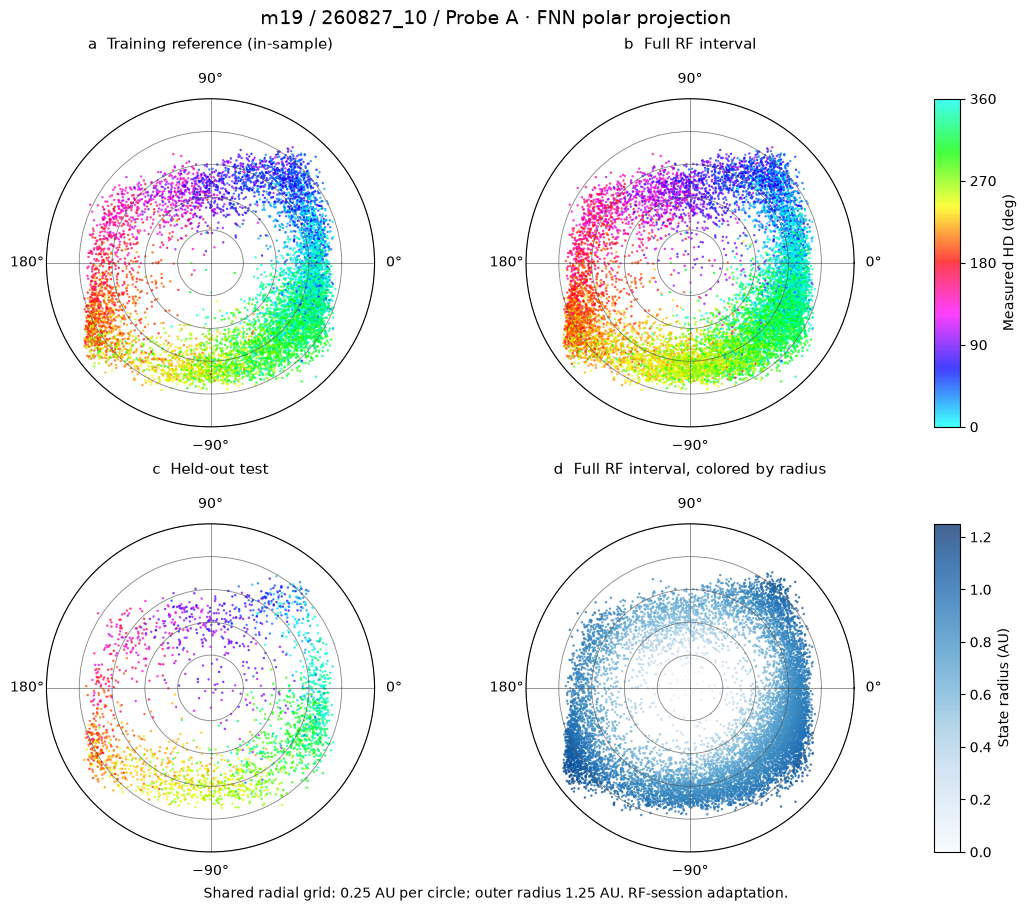

In [17]:
from matplotlib.colors import ListedColormap

angle_cmap = ListedColormap(plt.colormaps["hsv"]((np.linspace(0, 1, 256, endpoint=False) + 0.5) % 1))
projection_theta = np.deg2rad(decoded_hd)
radial_limit = np.ceil(radius.max() / 0.25) * 0.25
all_rows = np.ones(len(time), dtype=bool)
fig_projection = plt.figure(figsize=(10.5, 9), layout="constrained", facecolor="white")
grid = fig_projection.add_gridspec(2, 3, width_ratios=[1, 1, 0.055])
projection_axes = [fig_projection.add_subplot(grid[row, col], projection="polar")
                   for row, col in [(0, 0), (0, 1), (1, 0), (1, 1)]]
panels = [
    (train, "a  Training reference (in-sample)", hd_deg, angle_cmap, 360),
    (all_rows, "b  Full RF interval", hd_deg, angle_cmap, 360),
    (test, "c  Held-out test", hd_deg, angle_cmap, 360),
    (all_rows, "d  Full RF interval, colored by radius", radius, "Blues", radial_limit),
]
for ax, (rows, title, color, cmap, upper) in zip(projection_axes, panels):
    points = ax.scatter(projection_theta[rows], radius[rows], c=color[rows], cmap=cmap,
                        vmin=0, vmax=upper, s=3, alpha=0.75, edgecolors="none", rasterized=True)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_thetagrids([0, 90, 180, 270], ["0°", "90°", "180°", "−90°"])
    ax.set_ylim(0, radial_limit)
    ax.set_yticks(np.arange(0.25, radial_limit + 0.01, 0.25))
    ax.set_yticklabels([])
    ax.grid(color="#505050", linewidth=0.6, alpha=0.7)
    ax.set_facecolor("white")
    ax.set_title(title, fontsize=11, pad=17)
    if title.startswith("a"):
        angle_points = points
radius_points = points
fig_projection.colorbar(angle_points, cax=fig_projection.add_subplot(grid[0, 2]),
                        label="Measured HD (deg)", ticks=[0, 90, 180, 270, 360])
fig_projection.colorbar(radius_points, cax=fig_projection.add_subplot(grid[1, 2]),
                        label="State radius (AU)")
fig_projection.suptitle(f"{animal} / {date}_{session_id} / Probe A · FNN polar projection", fontsize=14)
fig_projection.supxlabel(f"Shared radial grid: 0.25 AU per circle; outer radius {radial_limit:g} AU. RF-session adaptation.", fontsize=10)
output_dir.mkdir(parents=True, exist_ok=True)
fig_projection.savefig(output_dir / "paper_projection.png", dpi=180, facecolor="white", transparent=False)
fig_projection.savefig(output_dir / "paper_projection.svg", facecolor="white", transparent=False)
np.testing.assert_allclose(radius * np.cos(projection_theta), z[:, 0], atol=1e-6)
np.testing.assert_allclose(radius * np.sin(projection_theta), z[:, 1], atol=1e-6)
plt.show()

## 9. Additional held-out diagnostics

The scatter uses the **unmultiplied** z coordinates and colors them by measured
HD. Radius is in arbitrary learned units. The loss constrains the product
g*z; compensating changes in g and z can preserve that product. Consequently,
radius is not uniquely identified as physiological network gain. A
radius–rate correlation can also reflect HD and shared inputs. This raw mean
rate is not the paper's network-gain estimate; its correlation does not test
the paper's gain claim.


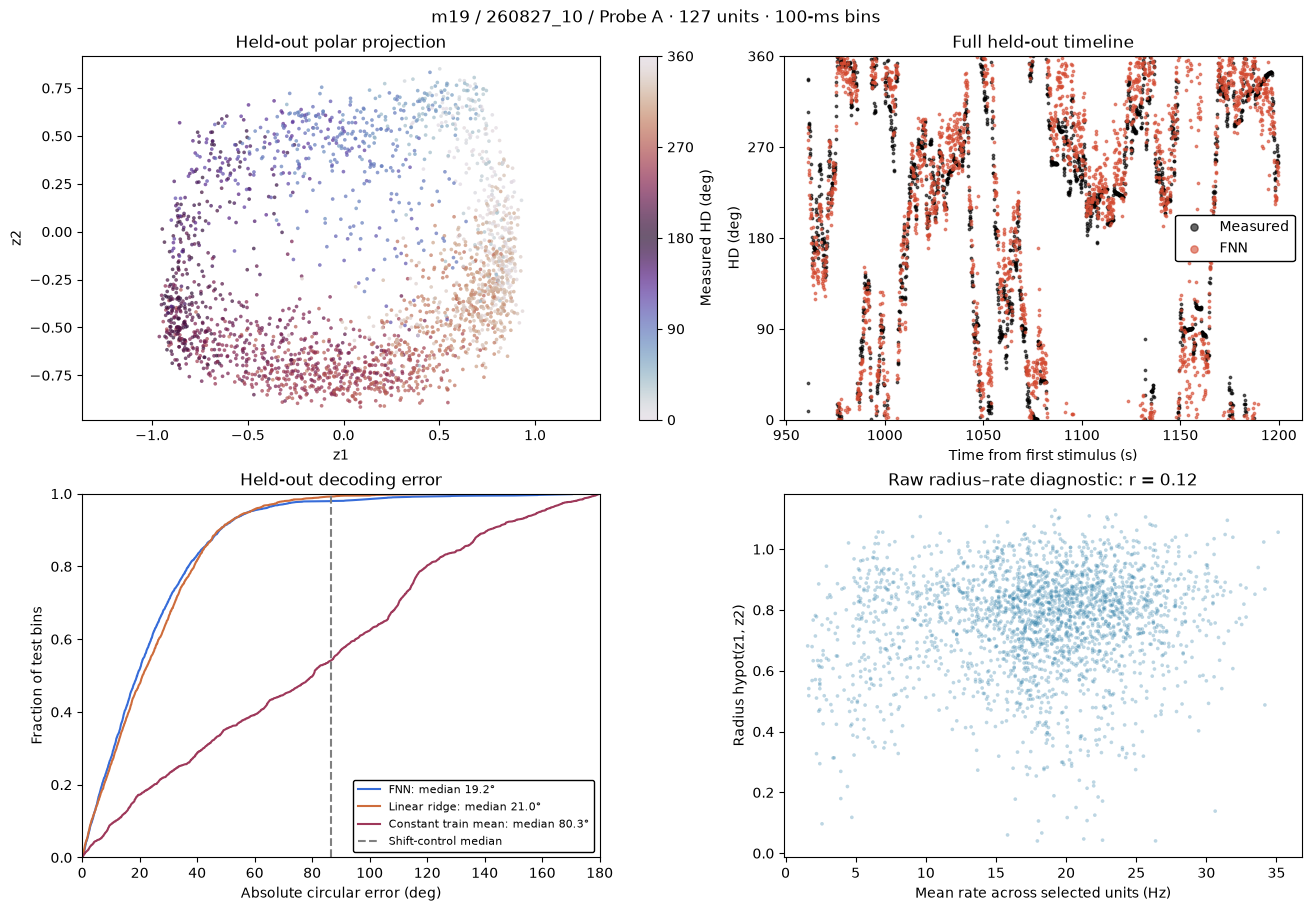

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout="constrained", facecolor="white")
points = axes[0, 0].scatter(
    z[test, 0], z[test, 1], c=hd_deg[test], cmap="twilight", vmin=0, vmax=360,
    s=7, alpha=0.7, edgecolors="none", rasterized=True,
)
axes[0, 0].set(xlabel="z1", ylabel="z2", title="Held-out polar projection")
axes[0, 0].set_aspect("equal", adjustable="datalim")
fig.colorbar(points, ax=axes[0, 0], label="Measured HD (deg)", ticks=[0, 90, 180, 270, 360])

test_time = time[test] - trial_edges[0]
axes[0, 1].scatter(test_time, hd_deg[test], s=3, color="black", alpha=0.6, label="Measured")
axes[0, 1].scatter(test_time, decoded_hd[test], s=3, color="#d44b32", alpha=0.6, label="FNN")
axes[0, 1].set(xlabel="Time from first stimulus (s)", ylabel="HD (deg)",
               yticks=[0, 90, 180, 270, 360], ylim=(0, 360), title="Full held-out timeline")
axes[0, 1].legend(markerscale=3)

for name, error in errors.items():
    axes[1, 0].plot(np.sort(error), np.arange(1, len(error) + 1) / len(error),
                    label=f"{name}: median {np.median(error):.1f}°")
axes[1, 0].axvline(np.median(shift_errors), color="gray", linestyle="--", label="Shift-control median")
axes[1, 0].set(xlabel="Absolute circular error (deg)", ylabel="Fraction of test bins",
               xlim=(0, 180), ylim=(0, 1), title="Held-out decoding error")
axes[1, 0].legend(fontsize=8)

axes[1, 1].scatter(rate[test].mean(axis=1), radius[test], s=7,
                    color="#267aa5", alpha=0.3, edgecolors="none", rasterized=True)
axes[1, 1].set(xlabel="Mean rate across selected units (Hz)", ylabel="Radius hypot(z1, z2)",
               title=f"Raw radius–rate diagnostic: r = {radius_rate_correlation:.2f}")
for ax in axes.flat:
    ax.set_facecolor("white")
fig.suptitle(f"{animal} / {date}_{session_id} / Probe A · {len(unit_ids)} units · {bin_size * 1000:g}-ms bins")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "validation.png", dpi=160, facecolor="white", transparent=False)
fig.savefig(output_dir / "validation.svg", facecolor="white", transparent=False)
plt.show()


## 10. Save the minimal reusable result

`model.pt` stores weights, unit ordering, and training normalization.
`samples.npz` stores raw counts, ADC times, split masks, true/decoded HD, z,
g, and both radius definitions. `manifest.json` records the exact source paths,
settings, file size/mtime, and control result. CSVs contain scores, splits,
selected unit IDs, training history, and shift errors.

The check below reloads the saved model and reconstructs test predictions
from the saved raw counts. It checks serialization and the complete
count → rate → normalization → FNN path.


In [19]:
settings = {
    "animal": animal, "date": date, "session_id": session_id, "probe": "A",
    "headplate": headplate, "bin_size_s": bin_size, "min_train_rate_hz": min_train_rate,
    "train_fraction": train_fraction, "validation_end_fraction": validation_end_fraction,
    "guard_s": guard_s, "camera_channel": camera_channel, "camera_threshold": camera_threshold,
    "seed": seed, "l2_weights": l2, "learning_rate": learning_rate,
    "batch_size": batch_size, "max_epochs": max_epochs, "patience": patience,
    "linear_ridge_alpha": 10.0, "best_epoch": best_epoch,
}
torch.save({
    "state_dict": model.state_dict(), "unit_ids": torch.from_numpy(unit_ids),
    "input_mean": torch.from_numpy(input_mean), "input_scale": torch.from_numpy(input_scale),
    "bin_size_s": bin_size,
}, output_dir / "model.pt")
np.savez_compressed(
    output_dir / "samples.npz", unit_ids=unit_ids, counts=counts,
    input_mean=input_mean, input_scale=input_scale, time_adc_s=time,
    bin_start_adc_s=sample_start, bin_end_adc_s=sample_end, hd_deg=hd_deg,
    train=train, validation=validation, test=test,
    decoded_hd_deg=decoded_hd, z=z, g=g, radius=radius, inverse_g=inverse_g,
    linear_test_hd_deg=linear_hd, constant_hd_deg=constant_hd,
)
metrics.to_csv(output_dir / "metrics.csv", index=False)
history.to_csv(output_dir / "training.csv", index=False)
split_summary.to_csv(output_dir / "splits.csv", index=False)
pd.DataFrame({"unit_id": unit_ids, "train_rate_hz": input_mean}).to_csv(output_dir / "units.csv", index=False)
pd.DataFrame({"shift_bins": shifts, "median_error_deg": shift_errors}).to_csv(output_dir / "shifts.csv", index=False)
manifest = {
    "paper": "https://www.nature.com/articles/s41586-023-05813-2",
    "data_reference": "../../glm/minimal_glm.ipynb",
    "settings": settings,
    "inputs": {name: {"path": str(path), "bytes": path.stat().st_size, "mtime_ns": path.stat().st_mtime_ns}
               for name, path in files.items()},
    "torch_version": str(torch.__version__), "numpy_version": np.__version__,
    "good_unit_count": good_unit_count, "selected_unit_count": len(unit_ids),
    "complete_camera_pulses": len(pulse_time), "usable_hd_frames": len(frame_time),
    "test_shift_control_median_deg": float(np.median(shift_errors)),
    "beats_constant_and_shift_controls": beats_controls,
    "radius_rate_correlation_descriptive": radius_rate_correlation,
    "raw_mean_rate_is_paper_gain": False,
    "polar_projection_file": "paper_projection.png",
    "test_median_product_norm_error": product_norm_error,
}
(output_dir / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")

saved = torch.load(output_dir / "model.pt", map_location="cpu", weights_only=True)
saved_samples = np.load(output_dir / "samples.npz")
restored = PolarFNN(len(saved["unit_ids"]))
restored.load_state_dict(saved["state_dict"])
restored.eval()
saved_rate = saved_samples["counts"][saved_samples["test"]].astype(np.float32) / saved["bin_size_s"]
saved_X = (torch.from_numpy(saved_rate) - saved["input_mean"]) / saved["input_scale"]
with torch.no_grad():
    restored_output, restored_z, _ = restored(saved_X)
np.testing.assert_allclose(restored_z.numpy(), saved_samples["z"][saved_samples["test"]], atol=1e-6)
np.testing.assert_allclose(restored_output.numpy(), output[test], atol=1e-6)
print("Saved-count/model round trip passed.")
print(f"Outputs: {output_dir}")


Saved-count/model round trip passed.
Outputs: /home/kai/Developer/rfmapping/fnn/outputs/m19_260827_10_probeA
